# Visualization 05 Discount Channel

Converted from `visualizations/05_discount_channel.py`.


In [1]:
# Notebook bootstrap generated from visualizations/05_discount_channel.py
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data_cleaning' else Path.cwd()
VISUALIZATIONS_DIR = PROJECT_ROOT / 'visualizations'
if str(VISUALIZATIONS_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATIONS_DIR))
os.chdir(VISUALIZATIONS_DIR)
__file__ = str(VISUALIZATIONS_DIR / '05_discount_channel.py')

from IPython.display import display

def inline_save(fig, name):
    display(fig)
    try:
        import matplotlib.pyplot as plt
        plt.close(fig)
    except Exception:
        pass
    print(f"  Displayed inline: {name}")
    return None


In [2]:
"""
05_discount_channel.py
Charts: discount depth vs repeat rate + LTV, marketplace vs website comparison,
        RFM segments, country mix
"""
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from style import save, TEAL, NAVY, ORANGE, RED, SLATE, GOLD, LIGHT_BG, LILAC

# Notebook override: display charts inline instead of writing PNG files.
save = inline_save



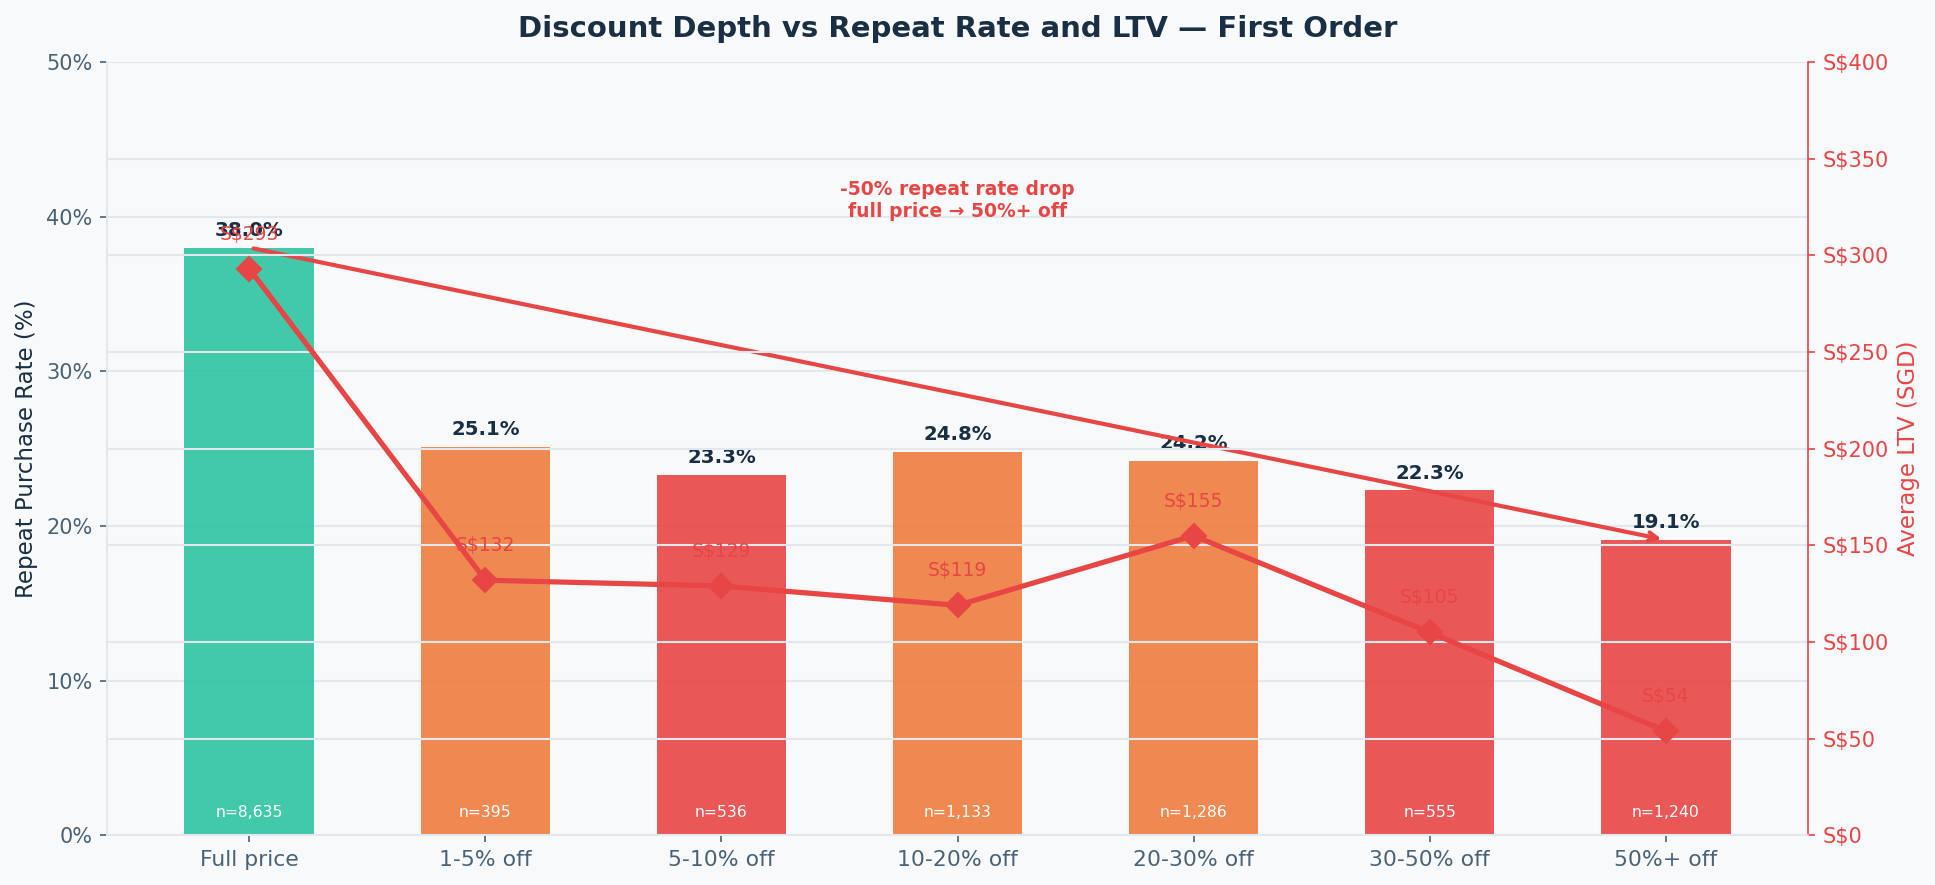

  Displayed inline: 05a_discount_depth_impact


In [3]:
# ── Chart 1: Discount depth — repeat rate and LTV ────────────────────────────
disc_bins   = ["Full price", "1-5% off", "5-10% off", "10-20% off", "20-30% off", "30-50% off", "50%+ off"]
rr_vals     = [38.0, 25.1, 23.3, 24.8, 24.2, 22.3, 19.1]
ltv_vals    = [293,  132,  129,  119,  155,  105,   54]
n_custs     = [8635, 395, 536, 1133, 1286, 555, 1240]

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(disc_bins))
bar_colors = [TEAL] + [ORANGE if r > 24 else RED for r in rr_vals[1:]]
bars = ax1.bar(x, rr_vals, color=bar_colors, width=0.55, zorder=3, alpha=0.9)
ax1.set_xticks(x); ax1.set_xticklabels(disc_bins, fontsize=10.5)
ax1.set_title("Discount Depth vs Repeat Rate and LTV — First Order")
ax1.set_ylabel("Repeat Purchase Rate (%)", fontsize=11, color=NAVY)
ax1.set_ylim(0, 50)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))

for bar, v, n in zip(bars, rr_vals, n_custs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=9.5, color=NAVY, fontweight="bold")
    ax1.text(bar.get_x()+bar.get_width()/2, 1,
             f"n={n:,}", ha="center", va="bottom", fontsize=7.5, color="white")

ax2 = ax1.twinx()
ax2.plot(x, ltv_vals, color=RED, marker="D", linewidth=2.5, markersize=8, zorder=4, label="Avg LTV")
ax2.set_ylabel("Average LTV (SGD)", color=RED, fontsize=11)
ax2.set_ylim(0, 400)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:.0f}"))
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(RED)
ax2.tick_params(axis="y", colors=RED)
for xi, v in enumerate(ltv_vals):
    ax2.text(xi, v+15, f"S${v}", ha="center", fontsize=9, color=RED)

# Arrow from full price to 50%+
ax1.annotate("", xy=(6, 19.1), xytext=(0, 38.0),
             arrowprops=dict(arrowstyle="->", color=RED, lw=2))
ax1.text(3, 40, "-50% repeat rate drop\nfull price → 50%+ off", ha="center",
         fontsize=9, color=RED, fontweight="bold")

fig.tight_layout()
save(fig, "05a_discount_depth_impact")



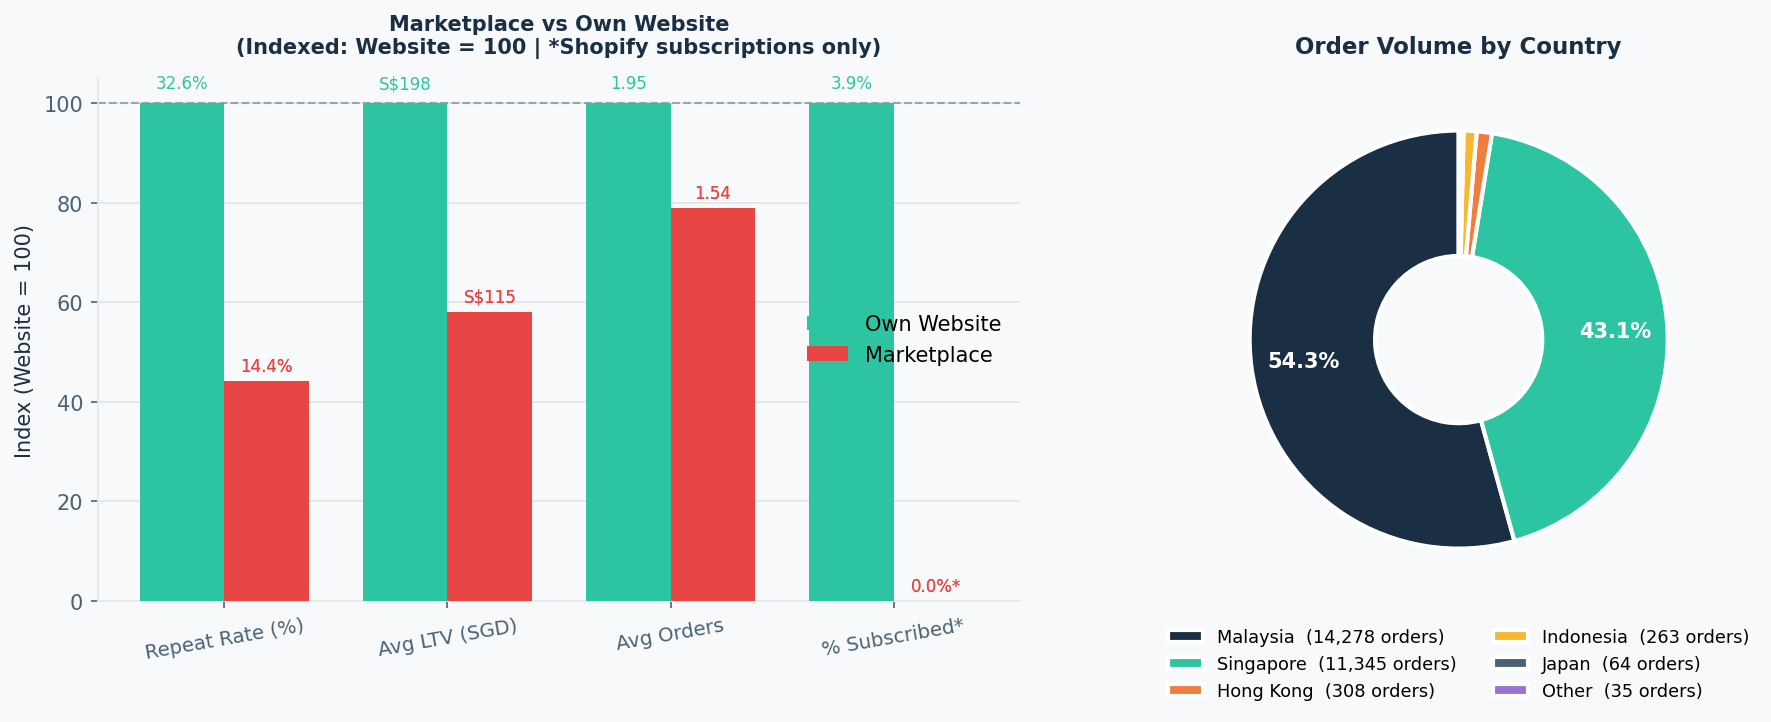

  Displayed inline: 05b_marketplace_vs_website


In [4]:
# ── Chart 2: Marketplace vs website spider/bar comparison ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

groups    = ["Marketplace", "Own Website\n(Direct+Paid+Email)"]
rr        = [14.4, 32.6]
ltv       = [115, 198]
avg_orders= [1.54, 1.95]
pct_sub   = [0.0, 3.9]

metrics_labels = ["Repeat Rate (%)", "Avg LTV (SGD)", "Avg Orders", "% Subscribed*"]
mkt_vals  = [14.4, 115, 1.54, 0.0]
web_vals  = [32.6, 198, 1.95, 3.9]

# Normalise to % of web value for visual comparison
mkt_norm  = [m/w*100 if w > 0 else 0 for m, w in zip(mkt_vals, web_vals)]
web_norm  = [100, 100, 100, 100]

x = np.arange(len(metrics_labels)); w = 0.38
b1 = axes[0].bar(x-w/2, web_norm,  width=w, color=TEAL, label="Own Website", zorder=3)
b2 = axes[0].bar(x+w/2, mkt_norm,  width=w, color=RED,  label="Marketplace",  zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_labels, fontsize=9.5, rotation=10)
axes[0].set_title("Marketplace vs Own Website\n(Indexed: Website = 100 | *Shopify subscriptions only)", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Index (Website = 100)", fontsize=10)
axes[0].legend()
axes[0].axhline(100, color=SLATE, linewidth=1, linestyle="--", alpha=0.5)

actual_web  = ["32.6%", "S$198", "1.95", "3.9%"]
actual_mkt  = ["14.4%", "S$115", "1.54", "0.0%*"]
for bar, lbl in zip(b1, actual_web):
    axes[0].text(bar.get_x()+bar.get_width()/2, 103, lbl, ha="center", fontsize=8, color=TEAL)
for bar, lbl in zip(b2, actual_mkt):
    axes[0].text(bar.get_x()+bar.get_width()/2, mkt_norm[list(b2).index(bar)]+2 if hasattr(bar,'get_height') else 5,
                 lbl, ha="center", fontsize=8, color=RED)

# Fix label placement for b2
for i, (bar, lbl, mn) in enumerate(zip(b2, actual_mkt, mkt_norm)):
    axes[0].text(bar.get_x()+bar.get_width()/2, mn+2, lbl, ha="center", fontsize=8, color=RED)

# Country mix
countries = ["Malaysia","Singapore","Hong Kong","Indonesia","Japan","Other"]
rev       = [3995393, 1570337, 19259, 10814, 1082, 3024]
order_n   = [14278, 11345, 308, 263, 64, 35]
c_colors  = [NAVY, TEAL, ORANGE, GOLD, SLATE, LILAC]

wedges, _, autotexts = axes[1].pie(
    order_n, labels=None,
    colors=c_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
legend_labels = [f"{c}  ({n:,} orders)" for c, n in zip(countries, order_n)]
axes[1].legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.22),
               ncol=2, fontsize=8.5)
axes[1].set_title("Order Volume by Country", fontsize=11, fontweight="bold")

fig.tight_layout()
save(fig, "05b_marketplace_vs_website")



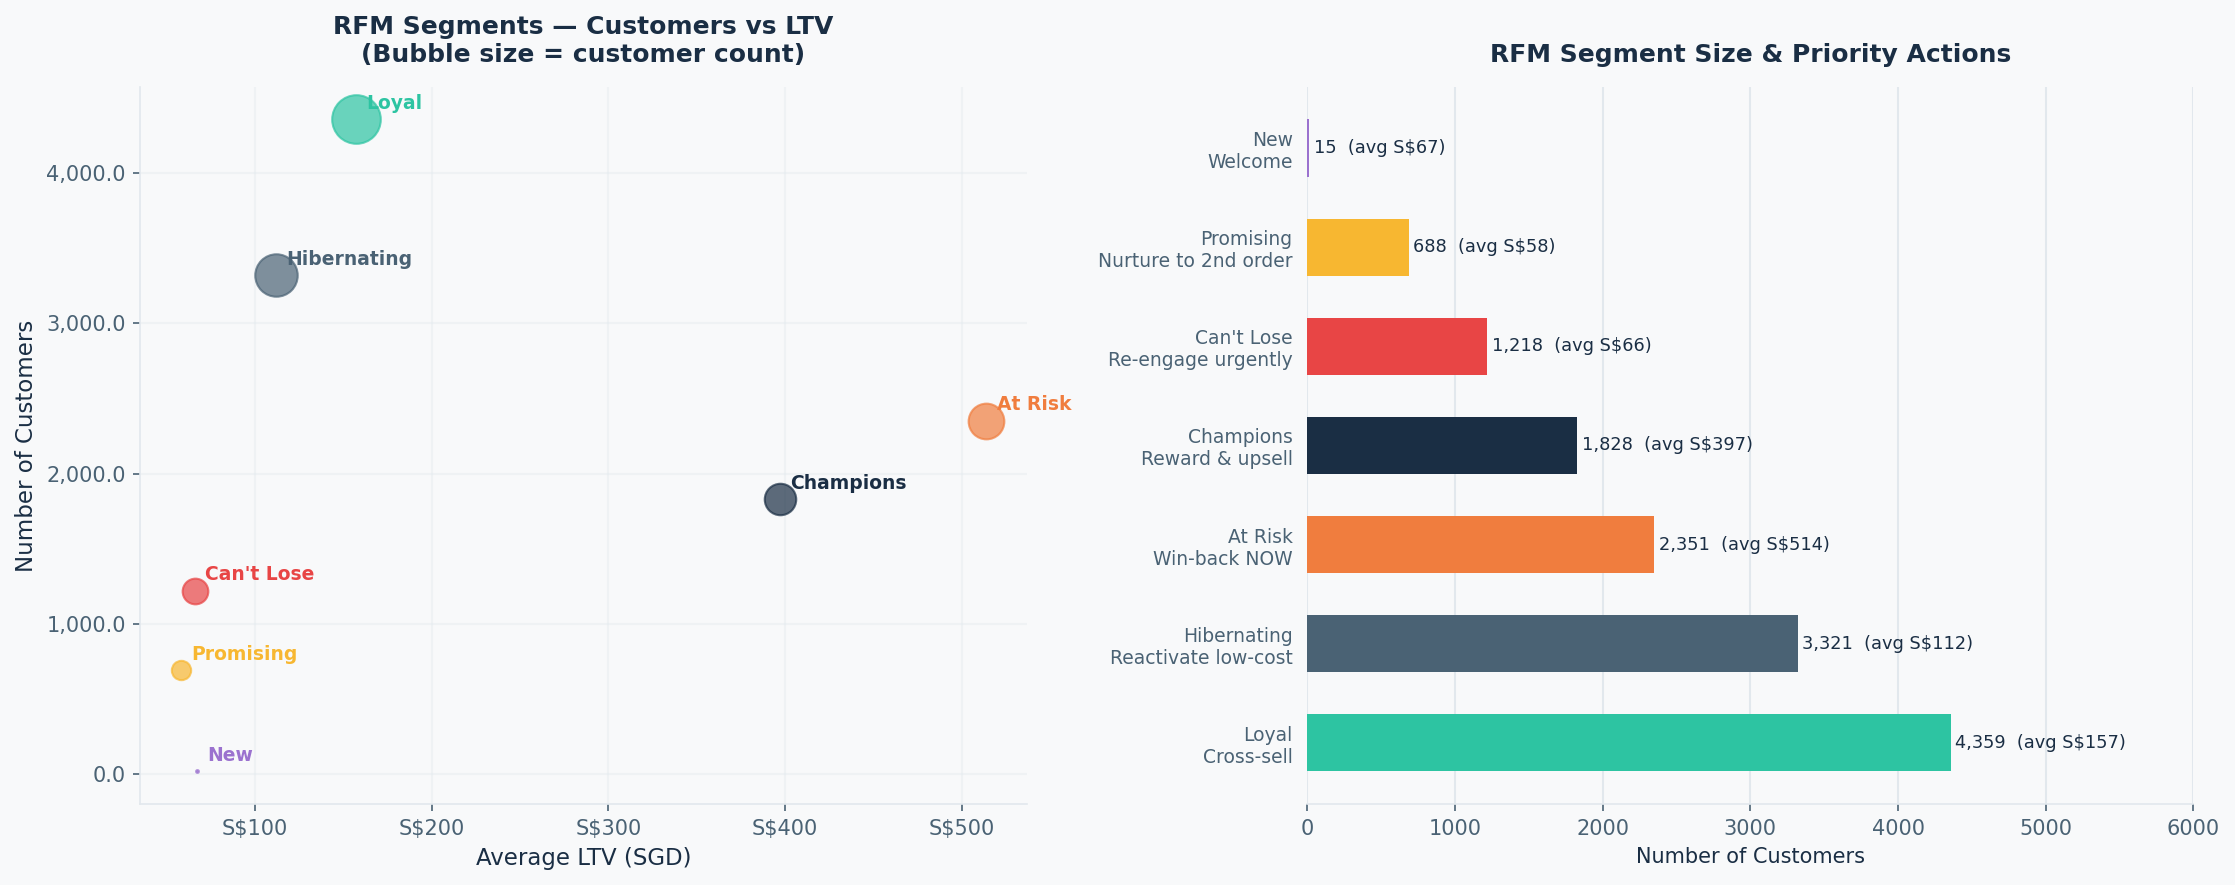

  Displayed inline: 05c_rfm_segments


In [5]:
# ── Chart 3: RFM segment breakdown ───────────────────────────────────────────
segments     = ["Loyal","Hibernating","At Risk","Champions","Can't Lose","Promising","New"]
seg_counts   = [4359, 3321, 2351, 1828, 1218, 688, 15]
seg_ltv      = [157, 112, 514, 397, 66, 58, 67]
seg_colors   = [TEAL, SLATE, ORANGE, NAVY, RED, GOLD, LILAC]
seg_priority = ["Cross-sell","Reactivate low-cost","Win-back NOW","Reward & upsell",
                "Re-engage urgently","Nurture to 2nd order","Welcome"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bubble-style: count vs LTV, bubble = count
ax = axes[0]
for i, (s, c, l, col) in enumerate(zip(segments, seg_counts, seg_ltv, seg_colors)):
    ax.scatter(l, c, s=c/8, color=col, alpha=0.7, zorder=3)
    ax.annotate(s, xy=(l, c), xytext=(5, 5), textcoords="offset points",
                fontsize=9, color=col, fontweight="bold")
ax.set_xlabel("Average LTV (SGD)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.set_title("RFM Segments — Customers vs LTV\n(Bubble size = customer count)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,}"))
ax.grid(True, alpha=0.4)

# Priority action table-style bar
y = np.arange(len(segments))
axes[1].barh(y, seg_counts, color=seg_colors, height=0.58, zorder=3)
axes[1].set_yticks(y)
axes[1].set_yticklabels([f"{s}\n{p}" for s, p in zip(segments, seg_priority)], fontsize=9)
axes[1].set_title("RFM Segment Size & Priority Actions", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Customers", fontsize=10)
for i, v in enumerate(seg_counts):
    axes[1].text(v+30, i, f"{v:,}  (avg S${seg_ltv[i]:,})", va="center", fontsize=8.5, color=NAVY)
axes[1].set_xlim(0, 6000)
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
axes[1].spines["left"].set_visible(False); axes[1].tick_params(left=False)

fig.tight_layout()
save(fig, "05c_rfm_segments")



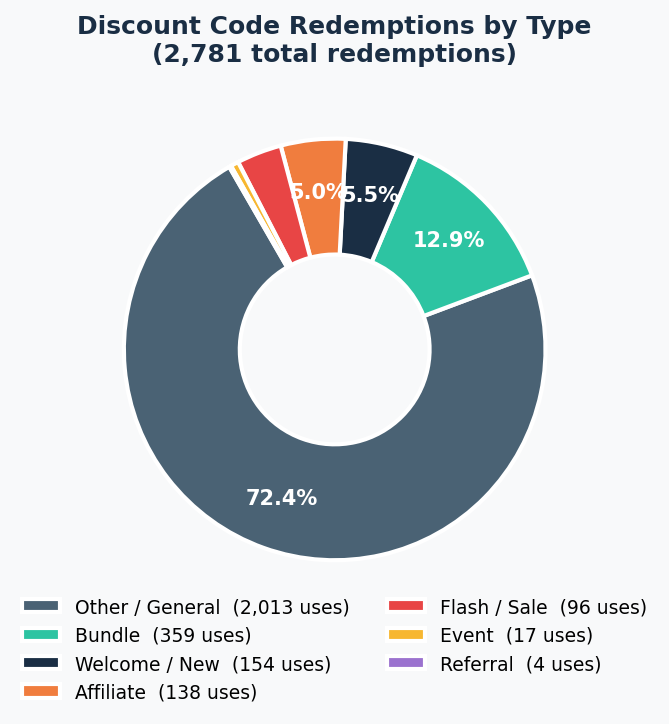

  Displayed inline: 05d_discount_code_taxonomy
Done – 05_discount_channel


In [6]:
# ── Chart 4: Discount code taxonomy ──────────────────────────────────────────
code_types  = ["Other / General","Bundle","Welcome / New","Affiliate","Flash / Sale","Event","Referral"]
redemptions = [2013, 359, 154, 138, 96, 17, 4]
type_colors = [SLATE, TEAL, NAVY, ORANGE, RED, GOLD, LILAC]

fig, ax = plt.subplots(figsize=(10, 5))
wedges, _, autotexts = ax.pie(
    redemptions, labels=None,
    colors=type_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
    startangle=120,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
legend_labels = [f"{t}  ({r:,} uses)" for t, r in zip(code_types, redemptions)]
ax.legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=9)
ax.set_title("Discount Code Redemptions by Type\n(2,781 total redemptions)", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "05d_discount_code_taxonomy")

print("Done – 05_discount_channel")
